In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Multilayer Perceptron
import pandas as pd
import numpy
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)
import tensorflow as tf



import tensorflow.keras
import math
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2DTranspose,Input, Reshape, Conv2D, Flatten
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import concatenate
import argparse
#from tensorflow.keras.utils.np_utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dropout
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from scipy.stats import pearsonr, spearmanr
from skimage import io

In [2]:
####################
####### Functions #############
####################

def custom_loss_2 (y_true, y_pred):
    A = tensorflow.keras.losses.mean_absolute_error(y_true, y_pred)
    #B = keras.losses.categorical_crossentropy(y_true[:,-4:], y_pred[:,-4:])
    return A





def lrelu(x): #from pix2pix code
    a=0.2
    # adding these together creates the leak part and linear part
    # then cancels them out by subtracting/adding an absolute value term
    # leak: a*x/2 - a*abs(x)/2
    # linear: x/2 + abs(x)/2

    # this block looks like it has 2 inputs on the graph unless we do this
    x = tf.identity(x)
    return (0.5 * (1 + a)) * x + (0.5 * (1 - a)) * tf.abs(x)

def lrelu_output_shape(input_shape):
    shape = list(input_shape)
    return tuple(shape)

from tensorflow.keras.layers import Lambda
layer_lrelu=Lambda(lrelu, output_shape=lrelu_output_shape, name='Leaky_ReLU')


def createOutputLabels(Labels):
    output=np.zeros(shape=(len(Labels),12))    
    
    for i in range(len(Labels)):
        for j in range (4):
            if Labels.iloc[i,j]=='CN':
                output[i,j*3]=1
                output[i,j*3+1]=0
                output[i,j*3+2]=0

                
            elif Labels.iloc[i,j]=='MCI':
                output[i,j*3]=0
                output[i,j*3+1]=1
                output[i,j*3+2]=0
                
            elif Labels.iloc[i,j]=='Dementia':
                output[i,j*3]=0
                output[i,j*3+1]=0
                output[i,j*3+2]=1
                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output

def create_image(labels):
    output=np.zeros(shape=(len(labels),3,4,3))    
    
    for i in range(len(labels)):
        for j in range (3):
                if j ==0:
                    output[i,j,:,1] = labels[i,j]
                elif j==1:
                     output[i,j,:,2] = labels[i,j]
                elif j ==2:
                    output[i,j,:,0] = labels[i,j]

                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output



def FnCreateValidLabes(Labels):
    return range(len(Labels))

In [4]:
n_splits=10


In [3]:
####################
###### Reading Data ##############    
####################    

# AllDataset = pandas.read_csv('Data_XY_BLD_CutOff.csv', low_memory=False)
AllDataset = pd.read_excel('dataset_final.xlsx')
AllDataset = AllDataset.set_index(AllDataset.ID)


AllDataset.columns

Index([                   'ID',                   'RID',
                        'PTID',               'VISCODE',
                        'SITE',               'COLPROT',
                    'ORIGPROT',              'EXAMDATE',
                       'DX_bl',                   'AGE',
                    'PTGENDER',              'PTEDUCAT',
                    'PTETHCAT',              'PTRACCAT',
                     'PTMARRY',                 'APOE4',
                         'FDG',                   'PIB',
                        'AV45',                 'ABETA',
                         'TAU',                  'PTAU',
                       'CDRSB',                'ADAS11',
                      'ADAS13',                'ADASQ4',
                        'MMSE',       'RAVLT_immediate',
              'RAVLT_learning',      'RAVLT_forgetting',
       'RAVLT_perc_forgetting',             'LDELTOTAL',
                   'DIGITSCOR',              'TRABSCOR',
                         'FAQ',

In [4]:
len(AllDataset)

5616

In [5]:
rid_counts = AllDataset.groupby('RID').size()

# Calculate statistics
min_count = rid_counts.min()
median_count = rid_counts.median()
mean_count = rid_counts.mean()
max_count = rid_counts.max()

# Display results
print(f"Min count: {min_count}")
print(f"Median count: {median_count}")
print(f"Mean count: {mean_count}")
print(f"Max count: {max_count}")

Min count: 1
Median count: 3.0
Mean count: 3.5930902111324374
Max count: 13


In [ ]:
# AllDataset = AllDataset[AllDataset["VISCODE"] == "m0"]

In [6]:
column_list = ["DX", "DX6", "DX12", "DX24"]

# Dictionary to store value counts for each column
value_counts_dict = {}

for col in column_list:
    value_counts_dict[col] = AllDataset[col].value_counts()

# Combine into a single DataFrame
result_df = pd.DataFrame(value_counts_dict).fillna(0).astype(int)

# Show the result
print(result_df)

            DX   DX6  DX12  DX24
Dementia  2196  2372  2504  2712
MCI       2041  1864  1720  1527
CN        1379  1380  1392  1377


In [7]:
# Example column list
column_list = ["DX", "DX6", "DX12", "DX24"]

# Function to label if diagnosis changed
def label_dx_change(row):
    initial = row["DX"]
    # Check if any future timepoints are different from the initial
    changed = any(pd.notna(row[col]) and row[col] != initial for col in column_list[1:])
    return f"{initial}_c" if changed else initial

# Apply function to create a new column
AllDataset["DX_status"] = AllDataset.apply(label_dx_change, axis=1)

# Count each unique label
dx_status_counts = AllDataset["DX_status"].value_counts()

print(dx_status_counts)


Dementia      2185
MCI           1441
CN            1301
MCI_c          600
CN_c            78
Dementia_c      11
Name: DX_status, dtype: int64


In [8]:


column_list = ["DX", "DX6", "DX12", "DX24"]
time_transitions = list(zip(column_list[:-1], column_list[1:]))

# Dictionary to hold conversion counts per timepoint
timepoint_conversion_counts = {}

for prev_col, curr_col in time_transitions:
    transition_series = AllDataset[[prev_col, curr_col]].dropna()
    
    # Filter rows where diagnosis changes
    transition_series = transition_series[transition_series[prev_col] != transition_series[curr_col]]
    
    # Create conversion label
    transitions = transition_series[prev_col] + "_" + transition_series[curr_col]
    
    # Count transitions
    transition_counts = transitions.value_counts()
    
    # Store in dictionary
    timepoint_conversion_counts[f"{prev_col}->{curr_col}"] = transition_counts

# Display results
for timepoint, counts in timepoint_conversion_counts.items():
    print(f"\nConversions for {timepoint}:")
    print(counts)



Conversions for DX->DX6:
MCI_Dementia    182
MCI_CN           12
CN_MCI           11
Dementia_MCI      6
dtype: int64

Conversions for DX6->DX12:
MCI_Dementia    136
MCI_CN           21
CN_MCI            9
Dementia_MCI      4
dtype: int64

Conversions for DX12->DX24:
MCI_Dementia    214
CN_MCI           64
MCI_CN           52
Dementia_MCI      9
CN_Dementia       3
dtype: int64


In [9]:
pd.set_option('display.float_format', '{:.4f}'.format)
regions = ['Ventricles', 'Hippocampus', 
              'Entorhinal', 'Fusiform', 'MidTemp', 'WholeBrain', 'ICV']
volume_means = AllDataset.groupby('DX')[regions].mean().round(4)
volume_median = AllDataset.groupby('DX')[regions].median().round(4)
volume_q1 = AllDataset.groupby('DX')[regions].quantile(0.25).round(4)
volume_q3 = AllDataset.groupby('DX')[regions].quantile(0.75).round(4)

In [10]:
volume_means

,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,WholeBrain,ICV
DX,,,,,,,
CN,35619.1917,7271.7442,3792.0541,17669.4850,20019.5220,1017548.4850,1519900.8390
Dementia,53037.7503,5552.1856,2710.9216,14995.8449,16642.2636,959464.6436,1545088.8382
MCI,41014.6000,6760.1241,3516.9827,17563.7438,19586.1692,1028670.5619,1547311.1919


In [11]:
volume_median

,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,WholeBrain,ICV
DX,,,,,,,
CN,31811.5000,7311.5000,3779.5000,17647.0000,19878.0000,1022750.0000,1508710.0000
Dementia,48954.0000,5476.0000,2655.0000,14884.0000,16586.0000,951628.0000,1526660.0000
MCI,36467.0000,6779.0000,3539.5000,17528.0000,19487.5000,1026090.0000,1541040.0000


In [12]:
volume_q1

,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,WholeBrain,ICV
DX,,,,,,,
CN,22162.0000,6623.0000,3372.0000,16085.2500,17999.5000,946580.5000,1408112.5000
Dementia,35028.0000,4743.5000,2186.5000,13064.0000,14647.0000,877670.0000,1412337.5000
MCI,24381.2500,5917.0000,2986.7500,15769.0000,17886.7500,953097.0000,1438677.5000


In [13]:
volume_q3

,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,WholeBrain,ICV
DX,,,,,,,
CN,42993.0000,7868.7500,4235.7500,19265.2500,21843.2500,1086897.5000,1621720.0000
Dementia,65524.0000,6246.5000,3156.5000,16712.0000,18484.0000,1033070.0000,1660062.5000
MCI,52517.2500,7610.0000,4061.2500,19300.7500,21628.5000,1103550.0000,1649422.5000


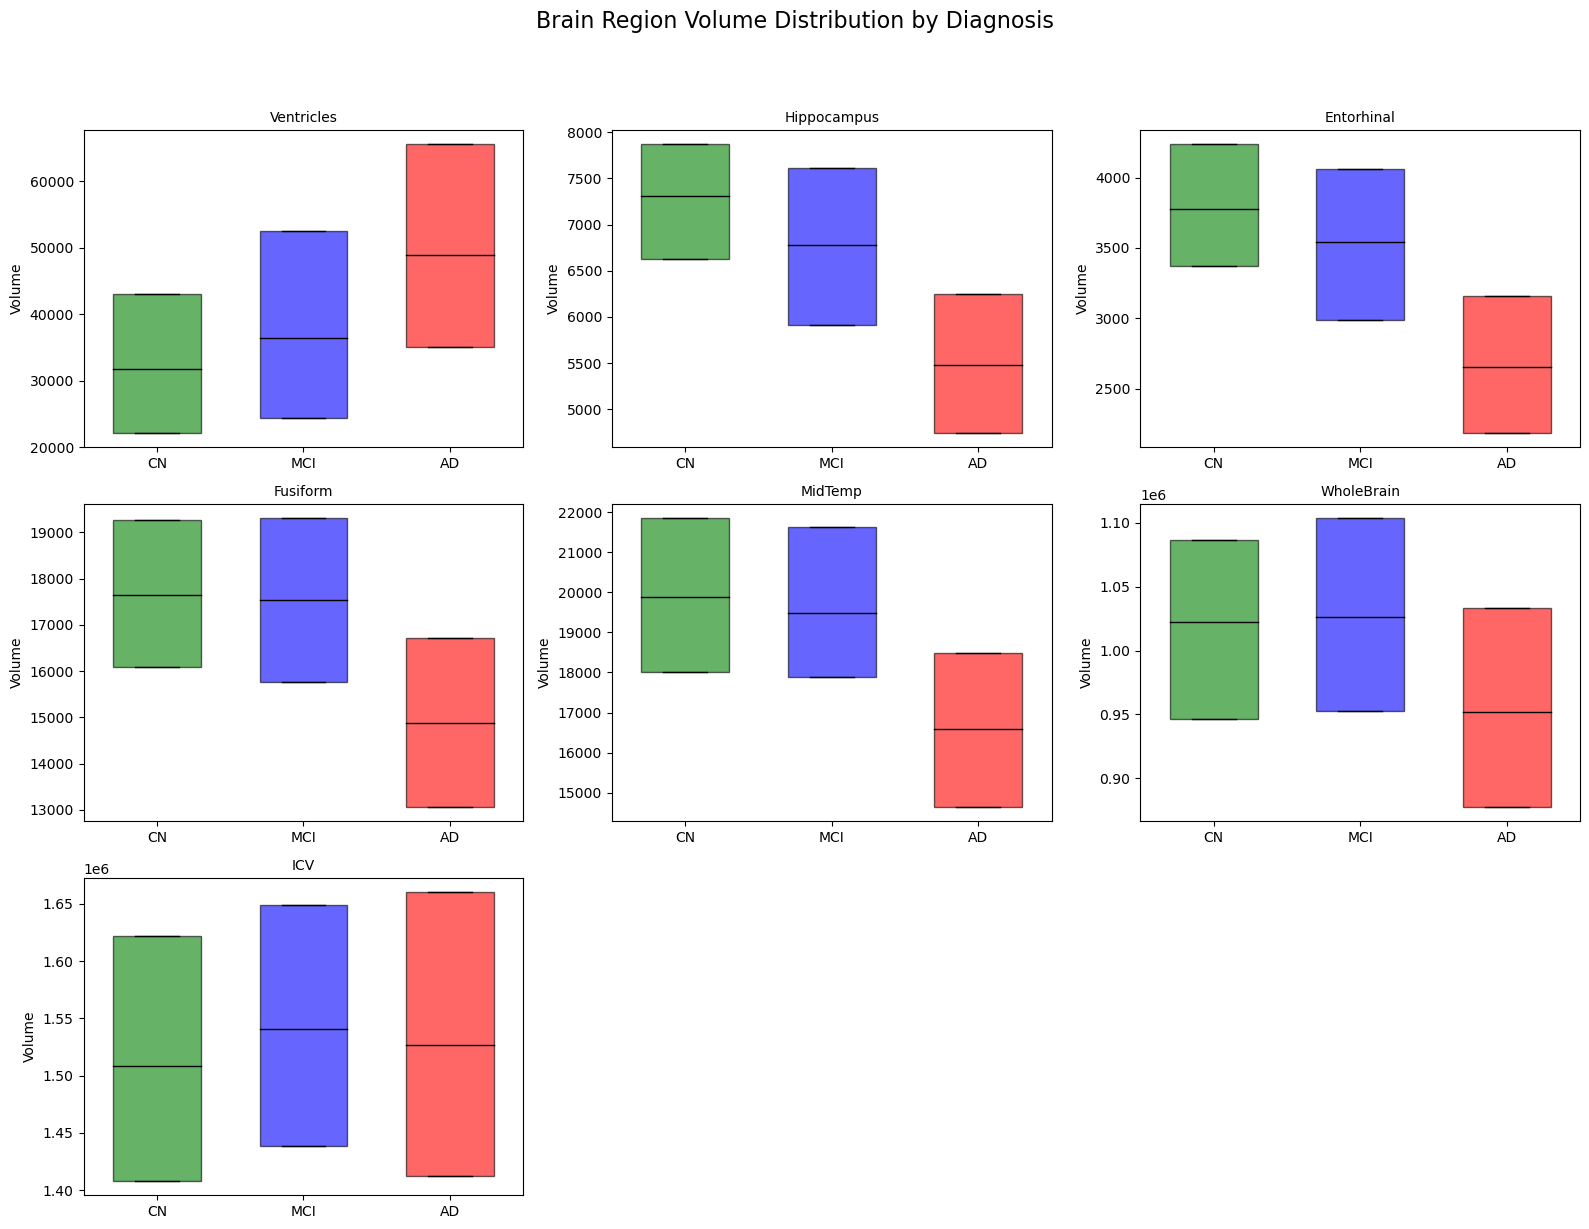

In [14]:
# Normalize AD to Dementia if needed
volume_q1 = volume_q1.rename(index={"AD": "Dementia"})
volume_q3 = volume_q3.rename(index={"AD": "Dementia"})
volume_median = volume_median.rename(index={"AD": "Dementia"})

# Diagnosis order and color mapping
dx_order = ["CN", "MCI", "Dementia"]
color_map = {
    "CN": "green",
    "MCI": "blue",
    "Dementia": "red"
}

# Create subplots (3 rows x 3 columns for 7 regions, with 2 empty spaces)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    for j, dx in enumerate(dx_order, start=1):
        q1 = volume_q1.loc[dx, region]
        q3 = volume_q3.loc[dx, region]
        median = volume_median.loc[dx, region]
        
        box = {
            'med': median,
            'q1': q1,
            'q3': q3,
            'whislo': q1,
            'whishi': q3,
            'fliers': []
        }

        ax.bxp([box], positions=[j], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor=color_map[dx], alpha=0.6),
               medianprops=dict(color='black'),
               showfliers=False)

    ax.set_title(region, fontsize=10)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["CN", "MCI", "AD"])
    ax.set_ylabel("Volume")

# Remove any extra/unused subplots
for k in range(len(regions), len(axes)):
    fig.delaxes(axes[k])

# Add overall title and layout adjustments
fig.suptitle("Brain Region Volume Distribution by Diagnosis", fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [15]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1379, 'missing_counts': Ventricles     273
Hippocampus    351
Entorhinal     381
Fusiform       381
MidTemp        381
WholeBrain     249
ICV            211
dtype: int64}, 'Dementia': {'total_subjects': 2196, 'missing_counts': Ventricles     682
Hippocampus    881
Entorhinal     997
Fusiform       997
MidTemp        997
WholeBrain     619
ICV            552
dtype: int64}, 'MCI': {'total_subjects': 2041, 'missing_counts': Ventricles     371
Hippocampus    534
Entorhinal     593
Fusiform       593
MidTemp        593
WholeBrain     320
ICV            285
dtype: int64}}


In [16]:
AllDataset[regions].head(7)

,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,WholeBrain,ICV
ID,,,,,,,
1,118233.0000,8336.0000,4177.0000,16559.0000,27936.0000,1229740.0000,1984660.0000
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,84599.0000,5319.0000,1791.0000,15506.0000,18422.0000,1129830.0000,1920690.0000
7,88580.0000,5446.0000,2427.0000,14400.0000,16972.0000,1100060.0000,1906430.0000


In [17]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

AllDataset[regions].head(7)

,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,WholeBrain,ICV
ID,,,,,,,
1,118233.0000,8336.0000,4177.0000,16559.0000,27936.0000,1229740.0000,1984660.0000
2,35619.1917,7271.7442,3792.0541,17669.4850,20019.5220,1017548.4850,1519900.8390
3,35619.1917,7271.7442,3792.0541,17669.4850,20019.5220,1017548.4850,1519900.8390
4,35619.1917,7271.7442,3792.0541,17669.4850,20019.5220,1017548.4850,1519900.8390
5,35619.1917,7271.7442,3792.0541,17669.4850,20019.5220,1017548.4850,1519900.8390
6,84599.0000,5319.0000,1791.0000,15506.0000,18422.0000,1129830.0000,1920690.0000
7,88580.0000,5446.0000,2427.0000,14400.0000,16972.0000,1100060.0000,1906430.0000


In [18]:
###################### MRI ######################
MRI_X = AllDataset.loc[:,['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']]
p=MRI_X.values

MRI_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
MRI_ID = AllDataset.ID
# normalize data
MRI_X = (MRI_X - MRI_X.min())/ (MRI_X.max() - MRI_X.min())
#MRI_X=MRI_X+1
MRI_X.head(10)

,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV
ID,,,,,,,
1,0.7167,0.6806,0.6938,0.6375,0.4172,0.8239,0.9099
2,0.1908,0.5622,0.4402,0.5582,0.4698,0.4960,0.5765
3,0.1908,0.5622,0.4402,0.5582,0.4698,0.4960,0.5765
4,0.1908,0.5622,0.4402,0.5582,0.4698,0.4960,0.5765
5,0.1908,0.5622,0.4402,0.5582,0.4698,0.4960,0.5765
6,0.5026,0.3449,0.5744,0.1460,0.3674,0.4298,0.8640
7,0.5280,0.3590,0.5388,0.2770,0.3151,0.3698,0.8538
8,0.5376,0.3269,0.5335,0.1059,0.3254,0.3846,0.8519
9,0.5842,0.3249,0.5251,0.0192,0.2977,0.3460,0.8516


In [19]:
regions = ['FDG', 'AV45']
means = AllDataset.groupby('DX')[regions].mean().round(4)
median = AllDataset.groupby('DX')[regions].median().round(4)
q1 = AllDataset.groupby('DX')[regions].quantile(0.25).round(4)
q3 = AllDataset.groupby('DX')[regions].quantile(0.75).round(4)

In [20]:
q3

,FDG,AV45
DX,,
CN,1.3780,1.1540
Dementia,1.1492,1.5318
MCI,1.3166,1.3392


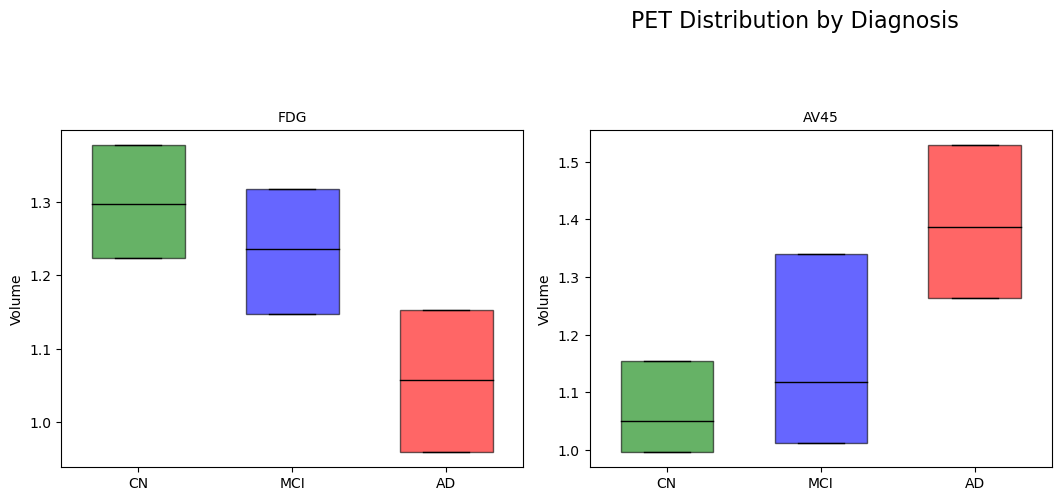

In [31]:
# Normalize AD to Dementia if needed
volume_q1 = q1.rename(index={"AD": "Dementia"})
volume_q3 = q3.rename(index={"AD": "Dementia"})
volume_median = median.rename(index={"AD": "Dementia"})

# Diagnosis order and color mapping
dx_order = ["CN", "MCI", "Dementia"]
color_map = {
    "CN": "green",
    "MCI": "blue",
    "Dementia": "red"
}

# Create subplots (3 rows x 3 columns for 7 regions, with 2 empty spaces)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    for j, dx in enumerate(dx_order, start=1):
        q1 = volume_q1.loc[dx, region]
        q3 = volume_q3.loc[dx, region]
        median = volume_median.loc[dx, region]
        
        box = {
            'med': median,
            'q1': q1,
            'q3': q3,
            'whislo': q1,
            'whishi': q3,
            'fliers': []
        }

        ax.bxp([box], positions=[j], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor=color_map[dx], alpha=0.6),
               medianprops=dict(color='black'),
               showfliers=False)

    ax.set_title(region, fontsize=10)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["CN", "MCI", "AD"])
    ax.set_ylabel("Volume")

# Remove any extra/unused subplots
for k in range(len(regions), len(axes)):
    fig.delaxes(axes[k])

# Add overall title and layout adjustments
fig.suptitle("PET Distribution by Diagnosis", fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [11]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': FDG     724
AV45    849
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': FDG     1421
AV45    1818
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': FDG     1053
AV45    1367
dtype: int64}}


In [12]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [13]:
###################### PET ######################
PET_X = AllDataset.loc[:,['FDG', 'AV45']]
PET_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
PET_ID = AllDataset.ID


# normalize data
PET_X = (PET_X - PET_X.min()) / (PET_X.max() - PET_X.min())
PET_X.head(5)

,FDG,AV45
ID,,
1,0.654938,0.159743
2,0.513175,0.159743
3,0.596599,0.159743
4,0.596599,0.159743
5,0.596599,0.159743


In [35]:
regions = ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']
means = AllDataset.groupby('DX')[regions].mean().round(4)
median = AllDataset.groupby('DX')[regions].median().round(4)
q1 = AllDataset.groupby('DX')[regions].quantile(0.25).round(4)
q3 = AllDataset.groupby('DX')[regions].quantile(0.75).round(4)

In [39]:
q3

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
DX,,,,,,,,,,,
CN,0.0000,30.0000,53.0000,8.0000,5.0000,50.0000,0.0000,28.0000,17.0000,54.0000,90.0000
Dementia,7.0000,25.0000,26.0000,3.0000,6.0000,100.0000,22.0000,20.0000,2.0000,36.0000,300.0000
MCI,2.0000,29.0000,41.0000,6.0000,6.0000,100.0000,5.0000,26.0000,11.0000,46.0000,132.0000


In [34]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': CDRSB                     10
MMSE                       1
RAVLT_immediate            3
RAVLT_learning             3
RAVLT_forgetting           3
RAVLT_perc_forgetting      5
FAQ                        6
MOCA                     645
LDELTOTAL                  2
DIGITSCOR                749
TRABSCOR                   7
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': CDRSB                      23
MMSE                       23
RAVLT_immediate           106
RAVLT_learning            106
RAVLT_forgetting          122
RAVLT_perc_forgetting     181
FAQ                        13
MOCA                     1232
LDELTOTAL                 530
DIGITSCOR                1137
TRABSCOR                  361
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': CDRSB                      13
MMSE                        6
RAVLT_immediate            11
RAVLT_learning             11
RAVLT_forgetting           12
RAVLT_perc_forge

In [16]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [17]:
###################### COG ######################
COG_X = AllDataset.loc[:, ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']]




COG_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
COG_RID = AllDataset.ID

# normalize data
COG_X = (COG_X - COG_X.min()) / (COG_X.max() - COG_X.min())
COG_X.head()

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
ID,,,,,,,,,,,
1,0.0,0.933333,0.586667,0.473684,0.666667,0.924242,0.0,0.860856,0.400000,0.409639,0.112450
2,0.0,0.933333,0.533333,0.421053,0.555556,0.895833,0.0,0.860856,0.563991,0.337349,0.125502
3,0.0,0.966667,0.453333,0.368421,0.703704,0.979167,0.0,0.860856,0.520000,0.397590,0.127510
4,0.0,0.933333,0.493333,0.526316,0.592593,0.900000,0.0,0.766667,0.480000,0.577101,0.166667
5,0.0,0.766667,0.560000,0.421053,0.629630,0.925926,0.0,0.733333,0.560000,0.577101,0.064257


In [41]:
regions = ['ABETA', 'PTAU', 'TAU']
means = AllDataset.groupby('DX')[regions].mean().round(4)
median = AllDataset.groupby('DX')[regions].median().round(4)
q1 = AllDataset.groupby('DX')[regions].quantile(0.25).round(4)
q3 = AllDataset.groupby('DX')[regions].quantile(0.75).round(4)

In [47]:
q3

,ABETA,PTAU,TAU
DX,,,
CN,1696.2500,27.1225,299.1000
Dementia,729.0500,43.0150,435.2500
MCI,1333.5000,34.7900,347.1000


In [42]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': ABETA    789
PTAU     789
TAU      789
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': ABETA    1693
PTAU     1693
TAU      1693
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': ABETA    1248
PTAU     1248
TAU      1248
dtype: int64}}


In [20]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [21]:
###################### CSF ######################
CSF_X = AllDataset.loc[:,['ABETA', 'PTAU', 'TAU']]
CSF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
CSF_RID = AllDataset.ID


# normalize data
CSF_X = (CSF_X - CSF_X.min()) / (CSF_X.max() - CSF_X.min())
CSF_X.head()

,ABETA,PTAU,TAU
ID,,,
1,0.666116,0.156392,0.201678
2,0.666116,0.156392,0.201678
3,0.666116,0.156392,0.201678
4,0.666116,0.156392,0.201678
5,0.666116,0.156392,0.201678


In [62]:
regions = ['AGE','PTEDUCAT']
means = AllDataset.groupby('DX')[regions].mean().round(4)
median = AllDataset.groupby('DX')[regions].median().round(4)
q1 = AllDataset.groupby('DX')[regions].quantile(0.25).round(4)
q3 = AllDataset.groupby('DX')[regions].quantile(0.75).round(4)

In [61]:
means

,AGE,PTEDUCAT,APOE4
DX,,,
CN,76.3256,16.4368,0.2838
Dementia,76.5736,15.4558,0.8616
MCI,74.5069,15.9917,0.5556


In [49]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}}


In [63]:
import pandas as pd

# Sample data setup (you should replace this with your actual DataFrame)
# data = pd.read_csv('your_file.csv')

# Define the region columns
region = ['APOE4', 'PTGENDER', 'PTETHCAT', 'PTRACCAT', 'PTMARRY']

# Create a dictionary to store unique values and counts for each region column
region_counts = {}

for col in region:
    # Group by the region column and 'DX', then count occurrences
    counts = AllDataset.groupby([col])['DX'].value_counts().unstack(fill_value=0)
    region_counts[col] = counts


region_counts

{'APOE4': DX        CN  Dementia   MCI
 APOE4                       
 0.0000  1013       723  1109
 1.0000   351      1063   756
 2.0000    21       418   194,
 'PTGENDER': DX         CN  Dementia   MCI
 PTGENDER                     
 Female    695       953   798
 Male      690      1263  1261,
 'PTETHCAT': DX                 CN  Dementia   MCI
 PTETHCAT                             
 Hisp/Latino        35        53    58
 Not Hisp/Latino  1342      2152  1996
 Unknown             8        11     5,
 'PTRACCAT': DX                   CN  Dementia   MCI
 PTRACCAT                               
 Am Indian/Alaskan     3         0     4
 Asian                18        42    38
 Black                77        73    44
 Hawaiian/Other PI     0         0     1
 More than one        13        14    18
 Unknown               0         0     3
 White              1274      2087  1951,
 'PTMARRY': DX               CN  Dementia   MCI
 PTMARRY                            
 Divorced        122        

In [24]:
###################### Risk Factor ######################
RF_X_1 = AllDataset.loc[:,['AGE','PTEDUCAT']]

RF_X_A = AllDataset.loc[:,['APOE4']]# ,'PTEDUCAT']] 


RF_X_gender = AllDataset.loc[:,['PTGENDER']]
RF_X_gender[RF_X_gender=='Male']=1
RF_X_gender[RF_X_gender=='Female']=2
RF_X_gender=RF_X_gender.fillna(3)

RF_X_ethnicity = AllDataset.loc[:,['PTETHCAT']]
RF_X_ethnicity[RF_X_ethnicity=='Not Hisp/Latino']=1
RF_X_ethnicity[RF_X_ethnicity=='Hisp/Latino']=2
RF_X_ethnicity[RF_X_ethnicity=='Unknown']=3
RF_X_ethnicity=RF_X_ethnicity.fillna(3)

RF_X_race = AllDataset.loc[:,['PTRACCAT']]
RF_X_race[RF_X_race=='White']=1
RF_X_race[RF_X_race=='Black']=2
RF_X_race[RF_X_race=='Asian']=3
RF_X_race[RF_X_race=='Am Indian/Alaskan']=4
RF_X_race[RF_X_race=='Hawaiian/Other PI']=5
RF_X_race[RF_X_race=='More than one']=6
RF_X_race[RF_X_race=='Unknown']=7
RF_X_race=RF_X_race.fillna(7)

RF_X_marry = AllDataset.loc[:,['PTMARRY']]
RF_X_marry[RF_X_marry=='Married']=1
RF_X_marry[RF_X_marry=='Widowed']=2
RF_X_marry[RF_X_marry=='Divorced']=3
RF_X_marry[RF_X_marry=='Never married']=4
RF_X_marry[RF_X_marry=='Unknown']=5
RF_X_marry=RF_X_marry.fillna(5)

import pandas as pd
# RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender, RF_X_marry ], axis=1)#, RF_X_sex
RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender, RF_X_ethnicity, RF_X_race, RF_X_marry ], axis=1)#, RF_X_sex



# normalize data
RF_X = (RF_X - RF_X.min()) / (RF_X.max() - RF_X.min())


RF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
RF_ID = AllDataset.ID

RF_X.head()

,AGE,PTEDUCAT,APOE4,PTGENDER,PTETHCAT,PTRACCAT,PTMARRY
ID,,,,,,,
1,0.470732,0.75,0.0,0.0,0.0,0.0,0.0
2,0.482927,0.75,0.0,0.0,0.0,0.0,0.0
3,0.543902,0.75,0.0,0.0,0.0,0.0,0.0
4,0.592683,0.75,0.0,0.0,0.0,0.0,0.0
5,0.617073,0.75,0.0,0.0,0.0,0.0,0.0


In [25]:
########################################
############## dataset cleaning #######
########################################

Labels_all_3class=COG_Y.iloc[:,-4:]

Labels_all_3class


,DX,DX6,DX12,DX24
ID,,,,
1,CN,CN,CN,CN
2,CN,CN,CN,CN
3,CN,CN,CN,CN
4,CN,CN,CN,MCI
5,CN,CN,CN,CN
...,...,...,...,...
5656,Dementia,Dementia,Dementia,Dementia
5657,Dementia,Dementia,Dementia,Dementia
5658,Dementia,Dementia,Dementia,Dementia


In [26]:
########################################
############## genreating input outputs from data #######
########################################

TargetTensors=createOutputLabels(Labels_all_3class)
#plt.imshow(TargetTensors[11,:,:,:])
#print(Labels_all_4class.iloc[11])


X_all=[MRI_X.values, PET_X.values, COG_X.values, 
       CSF_X.values, RF_X.values]

YTrain = COG_Y
YTrain1 = YTrain.reset_index()
Y_all_tensors=TargetTensors
X_all_IDs=RF_ID.values

In [27]:
from tensorflow.keras import backend as K

def grouped_softmax(x):
    """
    Activation function that applies softmax separately to groups of neurons
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        x: Input tensor
        
    Returns:
        Tensor with grouped softmax applied
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    group_outputs = []
    
    # Apply softmax to each group
    for start, end in groups:
        group = x[..., start:end]
        group_softmax = K.softmax(group, axis=-1)
        group_outputs.append(group_softmax)
    
    # Concatenate all groups back together
    return K.concatenate(group_outputs, axis=-1)

In [29]:
######################################################################################
################## NEtwork Architecture ##################################################
##########################################################################################

####################################### MRI FCN ###############################################
# mri FCN
MRI_inp_dim = MRI_X.shape[1]
MRI_visible = Input(shape=(MRI_inp_dim,), name='MRI')
hiddenMRI1 = Dense(25, activation='relu')(MRI_visible)
hiddenMRI1 = Dropout(0.2)(hiddenMRI1)
MRI_output = Dense(100, activation='relu')(hiddenMRI1)

####################################### PET FCN ###############################################
PET_inp_dim = PET_X.shape[1]
PET_visible = Input(shape=(PET_inp_dim,), name='PET')
hiddenPET2 = Dense(25, activation='relu')(PET_visible)
hiddenPET2 = Dropout(0.2)(hiddenPET2)
PET_output = Dense(100, activation='relu')(hiddenPET2)

####################################### COG FCN ###############################################
# mri FCN
COG_inp_dim = COG_X.shape[1]
COG_visible = Input(shape=(COG_inp_dim,), name='COG')
hiddenCOG1 = Dense(25, activation='relu')(COG_visible)
hiddenCOG1 = Dropout(0.2)(hiddenCOG1)
COG_output = Dense(100, activation='relu')(hiddenCOG1)

####################################### CSF FCN ###############################################
CSF_inp_dim = CSF_X.shape[1]
CSF_visible = Input(shape=(CSF_inp_dim,), name='CSF')
hiddenCSF2 = Dense(25, activation='relu')(CSF_visible)
hiddenCSF2 = Dropout(0.2)(hiddenCSF2)
CSF_output = Dense(100, activation='relu')(hiddenCSF2)

####################################### RF FCN ###############################################
RF_inp_dim = RF_X.shape[1]
RF_visible = Input(shape=(RF_inp_dim,), name='RF')
hiddenRF1 = Dense(25, activation='relu')(RF_visible)
hiddenRF1 = Dropout(0.2)(hiddenRF1)
RF_output = Dense(100, activation='relu')(hiddenRF1)

#################################### Concat FCN ###############################################

merge = concatenate([MRI_output, PET_output, COG_output, CSF_output,RF_output])
merge = Dropout(0.2)(merge)
# interpretation layer
hidden1 = Dense(500, activation='relu')(merge)
hidden1 = Dropout(0.2)(hidden1)

hidden2 = Dense(256, activation='relu')(hidden1)
hidden2 = Dropout(0.2)(hidden2)

hidden3 = Dense(128, activation='relu')(hidden2)
hidden3 = Dropout(0.2)(hidden3)

hidden4 = Dense(64, activation='relu')(hidden3)
hidden4 = Dropout(0.2)(hidden4)

hidden5 = Dense(32, activation='relu')(hidden4)
hidden5 = Dropout(0.2)(hidden5)

output = Dense(12, activation = grouped_softmax)(hidden5)
model_tensorization=Model(inputs= [MRI_visible, PET_visible, COG_visible, CSF_visible, RF_visible], outputs=output)  



model_tensorization.summary()
#dot_img_file = 'Network_23x23.png'


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 MRI (InputLayer)               [(None, 7)]          0           []                               
                                                                                                  
 PET (InputLayer)               [(None, 2)]          0           []                               
                                                                                                  
 COG (InputLayer)               [(None, 11)]         0           []                               
                                                                                                  
 CSF (InputLayer)               [(None, 3)]          0           []                               
                                                                                            

In [30]:
import tensorflow as tf
from tensorflow.keras.losses import BinaryCrossentropy

def grouped_binary_crossentropy(y_true, y_pred):
    """
    Custom loss function that calculates average binary cross entropy for groups of outputs
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        y_true: Ground truth values
        y_pred: Predicted values
        
    Returns:
        Average of binary cross entropy losses across the groups
    """
    # Initialize the binary cross entropy loss
    bce = BinaryCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
    
    # Define the groups
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    
    # Initialize list to store losses for each group
    group_losses = []
    
    # Calculate binary crossentropy for each group
    for start, end in groups:
        # Slice the predictions and true values for current group
        y_true_group = y_true[..., start:end]
        y_pred_group = y_pred[..., start:end]
        
        # Calculate binary crossentropy for the group
        loss = bce(y_true_group, y_pred_group)
        
        # Add to group losses
        group_losses.append(loss)
    
    # Stack all group losses
    all_losses = tf.stack(group_losses, axis=-1)
    
    # Calculate mean across groups
    mean_loss = tf.reduce_mean(all_losses, axis=-1)
    
    return mean_loss

In [31]:
from sklearn.model_selection import train_test_split
x = np.arange(0, len(X_all[1]),1)
train, test = train_test_split(x, shuffle=True, random_state=7, test_size=0.1)

Y_train_here_4Net=Y_all_tensors[train]
X_train_here_4Net=[X_all[0][train], X_all[1][train], X_all[2][train], X_all[3][train],X_all[4][train]]
X_train_here_names=X_all_IDs[train]

import time
model_tensorization.compile(loss=grouped_binary_crossentropy, optimizer='adam', metrics=['accuracy'])
model_tensorization.save_weights('SavedInitialWeights_tensors.weights.h5')
callback_1 = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=500, restore_best_weights=True)
callback_2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=800, restore_best_weights=True)

start_time = time.time()
History = model_tensorization.fit(X_train_here_4Net, Y_train_here_4Net, 
validation_split=0.1,  epochs=4000, batch_size=250,
    verbose=1 , callbacks=[callback_1, callback_2]) # , callbacks=[callback_1, callback_2]
elapsed_time = time.time() - start_time
print('----- train elapsed time:', elapsed_time)

Epoch 1/4000
19/19 [==============================] - 11s 103ms/step - loss: 0.6068 - accuracy: 0.0606 - val_loss: 0.4659 - val_accuracy: 0.0176
Epoch 2/4000
19/19 [==============================] - 1s 31ms/step - loss: 0.4477 - accuracy: 0.1272 - val_loss: 0.2869 - val_accuracy: 0.0961
Epoch 3/4000
19/19 [==============================] - 1s 39ms/step - loss: 0.3468 - accuracy: 0.1479 - val_loss: 0.2530 - val_accuracy: 0.1471
Epoch 4/4000
19/19 [==============================] - 1s 36ms/step - loss: 0.3038 - accuracy: 0.1931 - val_loss: 0.2404 - val_accuracy: 0.2216
Epoch 5/4000
19/19 [==============================] - 1s 35ms/step - loss: 0.2805 - accuracy: 0.2402 - val_loss: 0.2260 - val_accuracy: 0.2647
Epoch 6/4000
19/19 [==============================] - 1s 28ms/step - loss: 0.2671 - accuracy: 0.2524 - val_loss: 0.2097 - val_accuracy: 0.3608
Epoch 7/4000
19/19 [==============================] - 1s 31ms/step - loss: 0.2437 - accuracy: 0.2945 - val_loss: 0.1978 - val_accuracy: 0.34

In [32]:
X_test_here_4Net=[X_all[0][test], X_all[1][test], X_all[2][test], X_all[3][test], X_all[4][test]]
Y_test_here_4Net=Y_all_tensors[test]
X_test_here_names=X_all_IDs[test]
results = model_tensorization.evaluate(X_test_here_4Net, Y_test_here_4Net)
print(results)
output=model_tensorization.predict(X_test_here_4Net)


18/18 [==============================] - 0s 6ms/step - loss: 0.0959 - accuracy: 0.7845
[0.09593642503023148, 0.7844523191452026]
18/18 [==============================] - 1s 5ms/step


In [33]:
print(output[0])
print(Y_test_here_4Net[0])

[4.0465566e-05 9.9828458e-01 1.6749838e-03 3.9121477e-04 8.0413395e-01
 1.9547482e-01 5.2376097e-04 6.0973066e-01 3.8974550e-01 2.6404031e-03
 3.7982857e-01 6.1753106e-01]
[0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1.]


In [34]:
print(output[0])
print(Y_test_here_4Net[0])

[4.0465566e-05 9.9828458e-01 1.6749838e-03 3.9121477e-04 8.0413395e-01
 1.9547482e-01 5.2376097e-04 6.0973066e-01 3.8974550e-01 2.6404031e-03
 3.7982857e-01 6.1753106e-01]
[0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1.]


In [35]:
len(Y_test_here_4Net)

566

In [51]:
y_true = np.reshape(Y_test_here_4Net,(len(Y_test_here_4Net),4,3)).transpose(0, 2, 1)
y_true[0]

array([[0., 0., 0., 0.],
       [1., 1., 0., 0.],
       [0., 0., 1., 1.]])

In [37]:
output = np.round(output, 2)
y_pred = np.reshape(output,(len(output),4,3)).transpose(0, 2, 1)
y_pred[0]

array([[0.  , 0.  , 0.  , 0.  ],
       [1.  , 0.8 , 0.61, 0.38],
       [0.  , 0.2 , 0.39, 0.62]], dtype=float32)

In [38]:
y_true_img = create_image(y_true)
y_true_img[53,:,:,:]


array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 1.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]]])

In [39]:
def plot_output(img, y, title):
    plt.imshow(img)
    plt.title(title)

    # Set x-axis ticks and labels
    x_ticks = [0, 1, 2, 3]  # Adjust indices as per your data
    x_labels = ["T0", "T6", "T12", "T24"]

    plt.xticks(x_ticks, x_labels)

    # Set y-axis ticks and labels
    y_ticks = [0, 1,2]  # Adjust indices as per your data
    y_labels = ["CN", "MCI", "AD"]

    plt.yticks(y_ticks, y_labels)

    plt.axvline(x=0.5, color='grey', linewidth=2)
    plt.axvline(x=2.5, color='grey', linewidth=2)
    plt.axvline(x=1.5, color='grey',linewidth=2)
    plt.axvline(x=2.5, color='grey', linewidth=2)

    plt.axhline(y=0.5, color='grey', linestyle = '--', linewidth=1)
    plt.axhline(y=1.5, color='grey', linestyle = '--', linewidth=1)

    text_positions = [
        (0, 0, y[0,0]),
        (0, 1, y[1,0]), 
        (0, 2, y[2,0]), 
        (1, 0, y[0,1]),
        (1, 1, y[1,1]), 
        (1, 2, y[2,1]), 
        (2, 0, y[0,2]),
        (2, 1, y[1,2]), 
        (2, 2, y[2,2]), 
        (3, 0, y[0,3]),
        (3, 1, y[1,3]), 
        (3, 2, y[2,3]), 
        ]
    for x, y, label in text_positions:
        if label:
            plt.text(x, y, label, color='white', fontsize=12, ha='center', va='center')


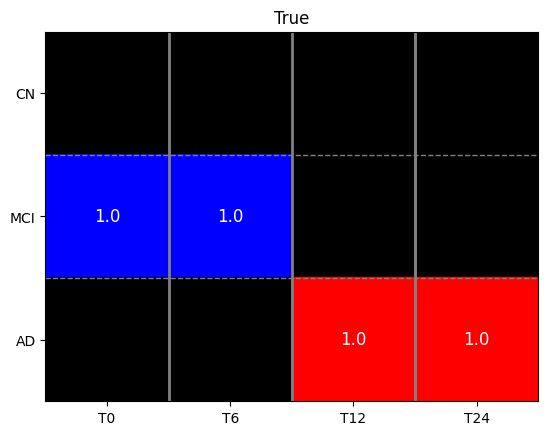

In [49]:
plot_output(y_true_img[0, :, :, :],y_true[0], "True" )

In [40]:
y_pred_img = create_image(y_pred)
y_pred_img[0,:,:,:]


array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 1.        ],
        [0.        , 0.        , 0.80000001],
        [0.        , 0.        , 0.61000001],
        [0.        , 0.        , 0.38      ]],

       [[0.        , 0.        , 0.        ],
        [0.2       , 0.        , 0.        ],
        [0.38999999, 0.        , 0.        ],
        [0.62      , 0.        , 0.        ]]])

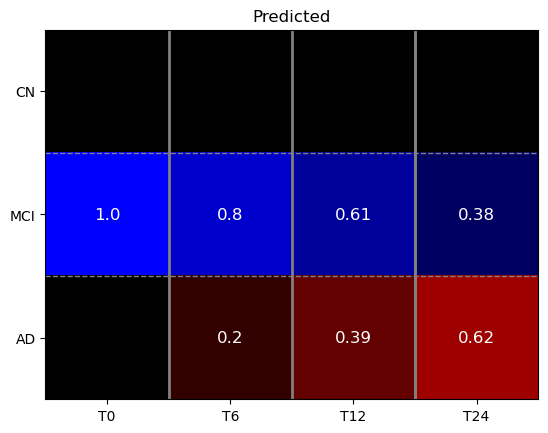

In [41]:
plot_output(y_pred_img[0,:,:,:],y_pred[0], "Predicted" )

In [42]:
X_test_here_names

array([ 719, 3426, 3064, 3645, 1324, 3033, 2841,  247, 3841, 3048, 2468,
        433, 2859, 1649,   57,  906, 1707, 2448, 4943, 2390, 5547,  826,
       4485, 3672,  319, 4915, 1730, 3903, 3810, 4492,  116, 3250,  162,
       2317, 4789, 5234, 5260, 4913, 2559, 3990,  453, 4874, 1650, 3655,
       2743, 1764, 3009, 3405, 5360,  954, 1210, 4393, 2396,   55, 4147,
       5237,  118, 1245,  447, 4362, 4509, 5345, 4691, 1194, 1741, 2980,
       4875, 2917, 2523, 1740, 2687, 2652, 4072, 3356, 4204, 2588, 1719,
       2070,  501, 2776, 4885,  276,  290, 1138, 3781, 1747, 1123, 1666,
       2569, 1043, 5133,  403, 3471, 5649, 4944,  180, 1391, 2435, 3716,
       1963, 1376, 4405,  831, 2168, 4933,  890, 5402, 5297, 1375, 3149,
       3695, 2117, 2306, 4155, 5363, 5202,   84, 5612, 3831, 5411,  434,
        699, 4580, 2939, 3893, 4057, 5534, 2457, 4917, 4227, 1812, 3837,
       2210, 3952, 4717,  597, 4122, 5553, 5441, 1648,  808, 2173, 2387,
       5154, 1283, 5010, 5447, 1142,  245, 3568, 12

In [43]:
X_test_here_names[0]

719

In [44]:
AllDataset.iloc[718]

ID                719
RID               258
PTID       128_S_0258
VISCODE           m12
SITE              128
              ...    
DX6               MCI
12             258m24
DX12         Dementia
24             258m36
DX24         Dementia
Name: 719, Length: 69, dtype: object

In [45]:
AllDataset.iloc[X_test_here_names[1]]["ID"]

3427

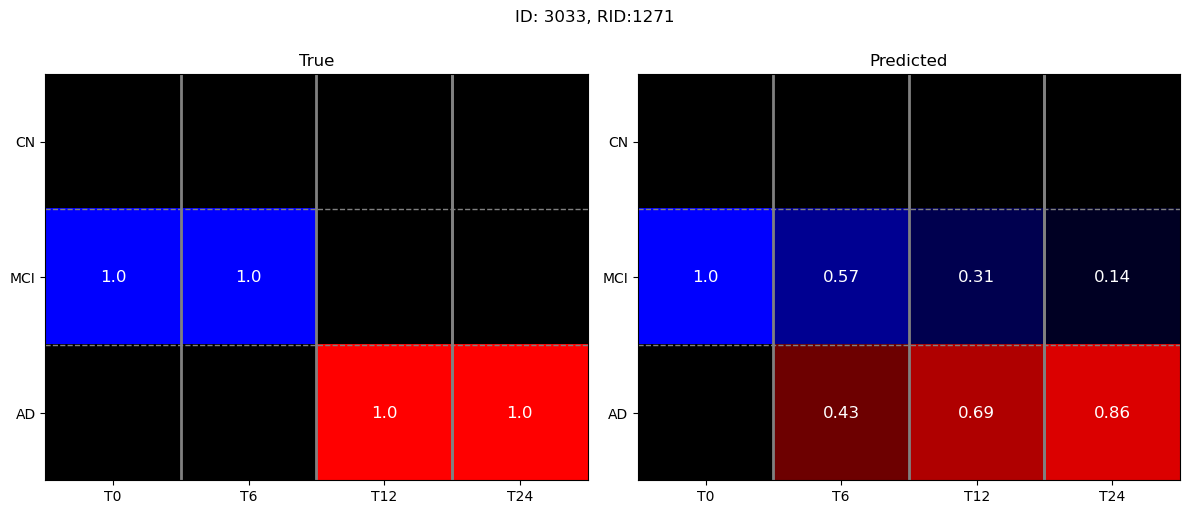

In [46]:
index = 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(f"ID: {X_test_here_names[index]}, RID:{AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]}")

plt.sca(axes[0])
plot_output(y_true_img[index, :, :, :], y_true[index], "True")

plt.sca(axes[1])
plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted")
plt.tight_layout(rect=[0, 0, 1, 0.95]) 

plt.show()

In [49]:
len(X_test_here_names)

566

In [48]:
for index in range(len(X_test_here_names)):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    fig.suptitle(f"ID: {X_test_here_names[index]}, RID:{AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]}")

    plt.sca(axes[0])
    plot_output(y_true_img[index, :, :, :], y_true[index], "True")

    plt.sca(axes[1])
    plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted")
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 

    plt.savefig(f"test_images/{index}.jpg", format = 'jpg', dpi=300)
    plt.close()
    

In [49]:
import matplotlib.pyplot as plt
y = Y_test_here_4Net[0]
reshaped = np.reshape(y,(4,3))
true = reshaped

y = np.round(Output[0],2)
reshaped = np.reshape(y,(4,3))
predicted = reshaped.transpose()
# plt.imshow(true)
print(true)


[[0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:
##########################################################################################
################## Training on folding ###################################################
##########################################################################################


# OPTIMIZER_1=tensorflow.keras.optimizers.RMSprop(lr=0.001, rho=0.9, epsilon=None, decay=0.0)
OPTIMIZER_2=tensorflow.keras.optimizers.Adam(lr=0.001, beta_1=0.99, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
# OPTIMIZER_3=tensorflow.keras.optimizers.Adam(lr=0.0001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)


import time
model_tensorization.compile(loss=custom_loss_2, optimizer=OPTIMIZER_2)
model_tensorization.save_weights('SavedInitialWeights_tensors.h5')
callback_1 = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=500, restore_best_weights=True)
callback_2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=800, restore_best_weights=True)


for repeator in range(0,1):

    kfold = StratifiedKFold(n_splits, shuffle=True, random_state=repeator)
    FoldCounter=0
    for train, test in kfold.split(X_all[1], COG_Y.iloc[:,-1].values):
        FoldCounter=FoldCounter+1   
        
        model_tensorization.load_weights('SavedInitialWeights_tensors.h5')        
        Y_train_here_4Net=Y_all_tensors[train,:,:,:]
        X_train_here_4Net=[X_all[0][train], X_all[1][train], X_all[2][train], X_all[3][train],X_all[4][train]]
        X_train_here_names=X_all_RIDs[train]
        
        print('---Repeat No:  ', repeator+1, '  ---Fold No:  ', FoldCounter)        
        
        start_time = time.time()
        History = model_tensorization.fit(X_train_here_4Net, Y_train_here_4Net, 
        validation_split=0.1,  epochs=a.max_epochs, batch_size=a.BatchSize,
         verbose=1 , callbacks=[callback_1, callback_2]) # , callbacks=[callback_1, callback_2]
        elapsed_time = time.time() - start_time
        print('----- train elapsed time:', elapsed_time)


        # summarize history for loss
        plt.plot(History.history['loss'])
        plt.plot(History.history['val_loss'])
        plt.title('model loss')
        plt.ylabel('loss')
        plt.xlabel('epoch')
        plt.grid()
        plt.legend(['train', 'val'], loc='upper left')
        plt.savefig(a.output+'Fold_'+str(FoldCounter)+'_History.png')
        plt.close()

        X_test_here_4Net=[X_all[0][test], X_all[1][test], X_all[2][test], X_all[3][test], X_all[4][test]]
        Y_test_here_4Net=Y_all_tensors[test,:,:,:]
        X_test_here_names=X_all_RIDs[test]
        
        for i in range(len(test)):            
            plt.figure()
            plt.subplot(122)
            
            start_time = time.time()
            Output=model_tensorization.predict(X_test_here_4Net)[i,:,:,:]
            elapsed_time = time.time() - start_time
            print('----- test elapsed time for one subject:', elapsed_time)
            plt.imshow(((Output)))

            plt.subplot(121)
            plt.imshow(Y_test_here_4Net[i,:,:,:])
            plt.savefig(a.output+'Fold_'+str(FoldCounter)+ '_Test_RID_'+str(X_test_here_names[i]), dpi=300)
            plt.close()
            
            io.imsave(outputFolderChild+'Fold_'+str(FoldCounter)+ '_Test_RID_'+str(X_test_here_names[i])+'_output.png',model_tensorization.predict(X_test_here_4Net)[i,:,:,:])
            io.imsave(outputFolderChild+'Fold_'+str(FoldCounter)+ '_Test_RID_'+str(X_test_here_names[i])+'_target.png',Y_test_here_4Net[i,:,:,:])
            
            
        for i in range(0,100,2):
            plt.figure()
            plt.subplot(122)
        
            
            plt.imshow(((model_tensorization.predict(X_train_here_4Net)[i,:,:,:])))

            
            plt.subplot(121)
            plt.imshow(Y_train_here_4Net[i,:,:,:])
            plt.savefig(a.output+'Fold_'+str(FoldCounter)+'_Trained_RID_'+str(X_train_here_names[i]), dpi=300)
            plt.close()
        
            io.imsave(outputFolderChild+'Fold_'+str(FoldCounter)+ '_Train_RID_'+str(X_train_here_names[i])+'_output.png',model_tensorization.predict(X_train_here_4Net)[i,:,:,:])
            io.imsave(outputFolderChild+'Fold_'+str(FoldCounter)+ '_Train_RID_'+str(X_train_here_names[i])+'_target.png',Y_train_here_4Net[i,:,:,:])
